In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load both datasets
baseline = pd.read_csv("baseline_result.csv")
music = pd.read_csv("music_result.csv")

print(f"Baseline samples: {len(baseline)}")
print(f"Music samples: {len(music)}")

Baseline samples: 1138
Music samples: 1138


In [3]:
# Get frequency columns (exclude Duration column)
freq_columns = [col for col in baseline.columns if 'KHZ' in col]

# Extract frequency data for both datasets
baseline_freq = baseline[freq_columns]
music_freq = music[freq_columns]

print(f"Baseline - Samples: {len(baseline)}, Frequency bins: {len(freq_columns)}")
print(f"Music - Samples: {len(music)}, Frequency bins: {len(freq_columns)}")
print(f"\nBaseline data shape: {baseline_freq.shape}")
print(f"Music data shape: {music_freq.shape}")

Baseline - Samples: 1138, Frequency bins: 511
Music - Samples: 1138, Frequency bins: 511

Baseline data shape: (1138, 511)
Music data shape: (1138, 511)


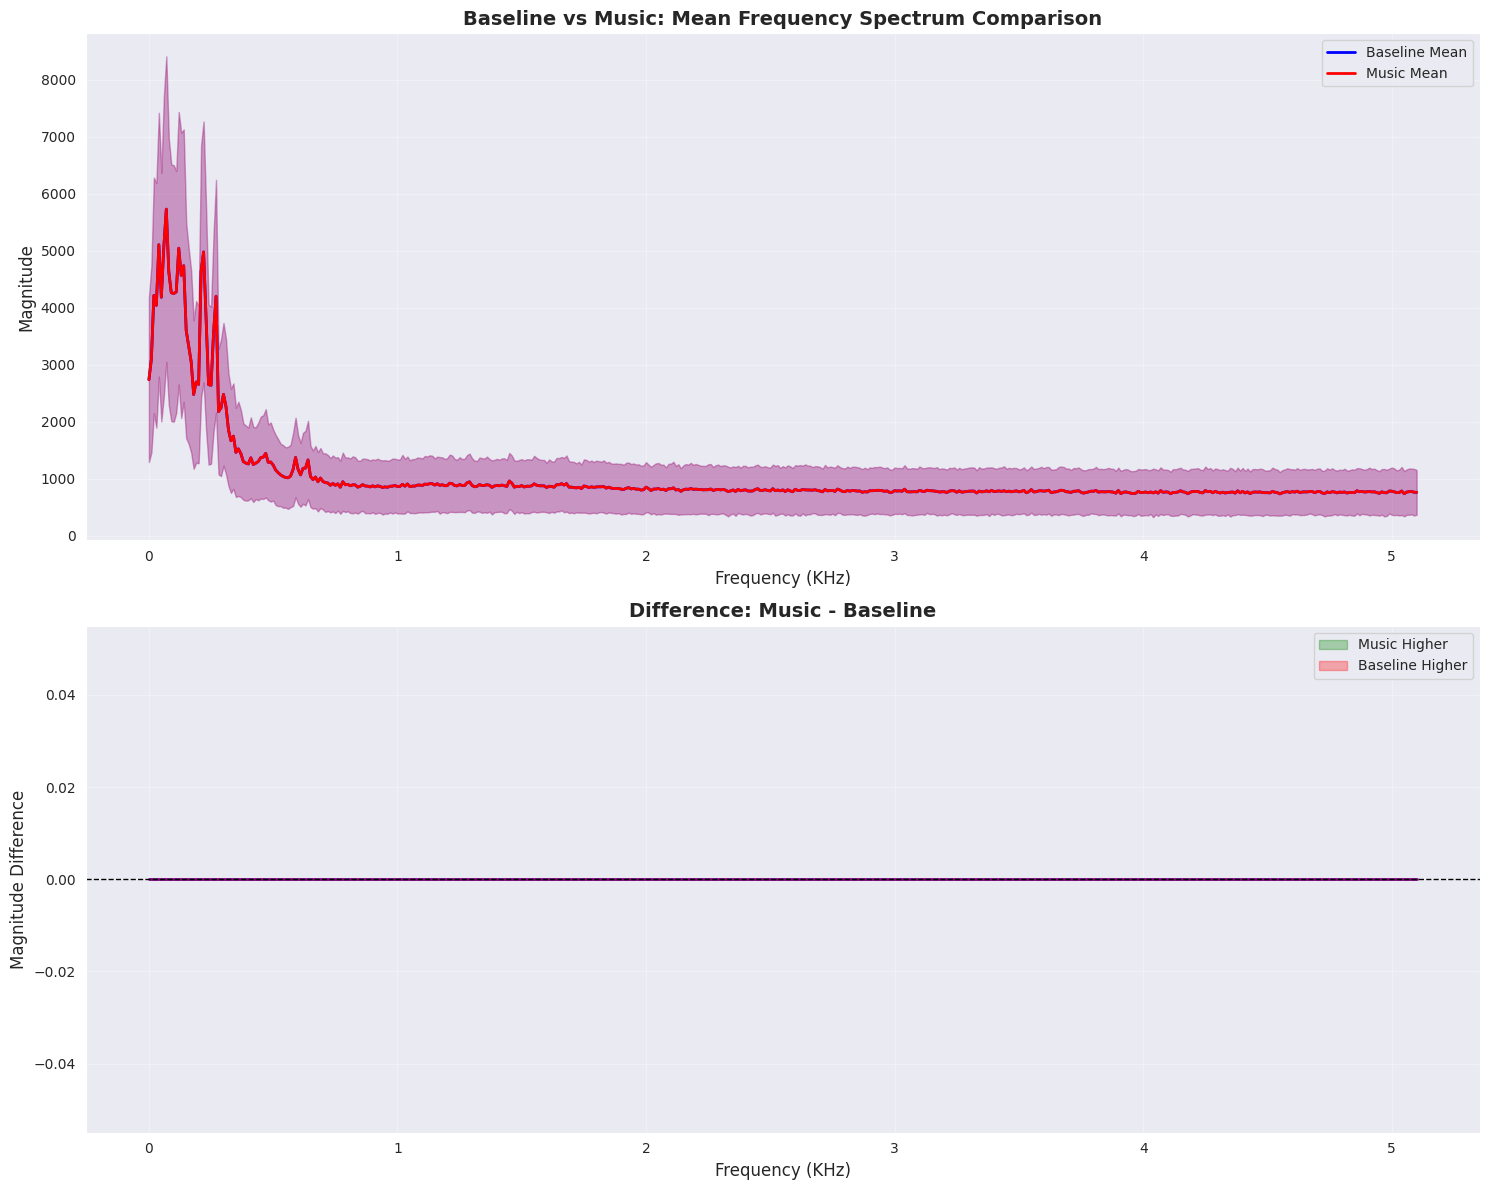

Baseline Peak:
  Frequency: 0.07 KHz
  Magnitude: 5732.788874

Music Peak:
  Frequency: 0.07 KHz
  Magnitude: 5732.788874

Largest Positive Difference (Music > Baseline):
  Frequency: 0.00 KHz
  Difference: 0.000000

Largest Negative Difference (Baseline > Music):
  Frequency: 0.00 KHz
  Difference: 0.000000


In [4]:
# Calculate statistics for both datasets
baseline_mean = baseline_freq.mean(axis=0)
baseline_std = baseline_freq.std(axis=0)
music_mean = music_freq.mean(axis=0)
music_std = music_freq.std(axis=0)

# Create frequency axis (in KHz)
frequencies = np.arange(len(freq_columns)) * 0.01  # 0.01 KHz bins

# Plot comparison of mean spectra
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Top plot: Overlaid mean spectra with standard deviation
ax1.plot(frequencies, baseline_mean, linewidth=2, label='Baseline Mean', color='blue')
ax1.fill_between(frequencies, 
                 baseline_mean - baseline_std, 
                 baseline_mean + baseline_std, 
                 alpha=0.2, color='blue')

ax1.plot(frequencies, music_mean, linewidth=2, label='Music Mean', color='red')
ax1.fill_between(frequencies, 
                 music_mean - music_std, 
                 music_mean + music_std, 
                 alpha=0.2, color='red')

ax1.set_xlabel('Frequency (KHz)', fontsize=12)
ax1.set_ylabel('Magnitude', fontsize=12)
ax1.set_title('Baseline vs Music: Mean Frequency Spectrum Comparison', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Bottom plot: Difference (Music - Baseline)
difference = music_mean - baseline_mean
ax2.plot(frequencies, difference, linewidth=2, color='purple')
ax2.fill_between(frequencies, 0, difference, where=(difference > 0), 
                 alpha=0.3, color='green', label='Music Higher')
ax2.fill_between(frequencies, 0, difference, where=(difference < 0), 
                 alpha=0.3, color='red', label='Baseline Higher')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Frequency (KHz)', fontsize=12)
ax2.set_ylabel('Magnitude Difference', fontsize=12)
ax2.set_title('Difference: Music - Baseline', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print("Baseline Peak:")
print(f"  Frequency: {frequencies[np.argmax(baseline_mean)]:.2f} KHz")
print(f"  Magnitude: {baseline_mean.max():.6f}")
print("\nMusic Peak:")
print(f"  Frequency: {frequencies[np.argmax(music_mean)]:.2f} KHz")
print(f"  Magnitude: {music_mean.max():.6f}")
print("\nLargest Positive Difference (Music > Baseline):")
print(f"  Frequency: {frequencies[np.argmax(difference)]:.2f} KHz")
print(f"  Difference: {difference.max():.6f}")
print("\nLargest Negative Difference (Baseline > Music):")
print(f"  Frequency: {frequencies[np.argmin(difference)]:.2f} KHz")
print(f"  Difference: {difference.min():.6f}")

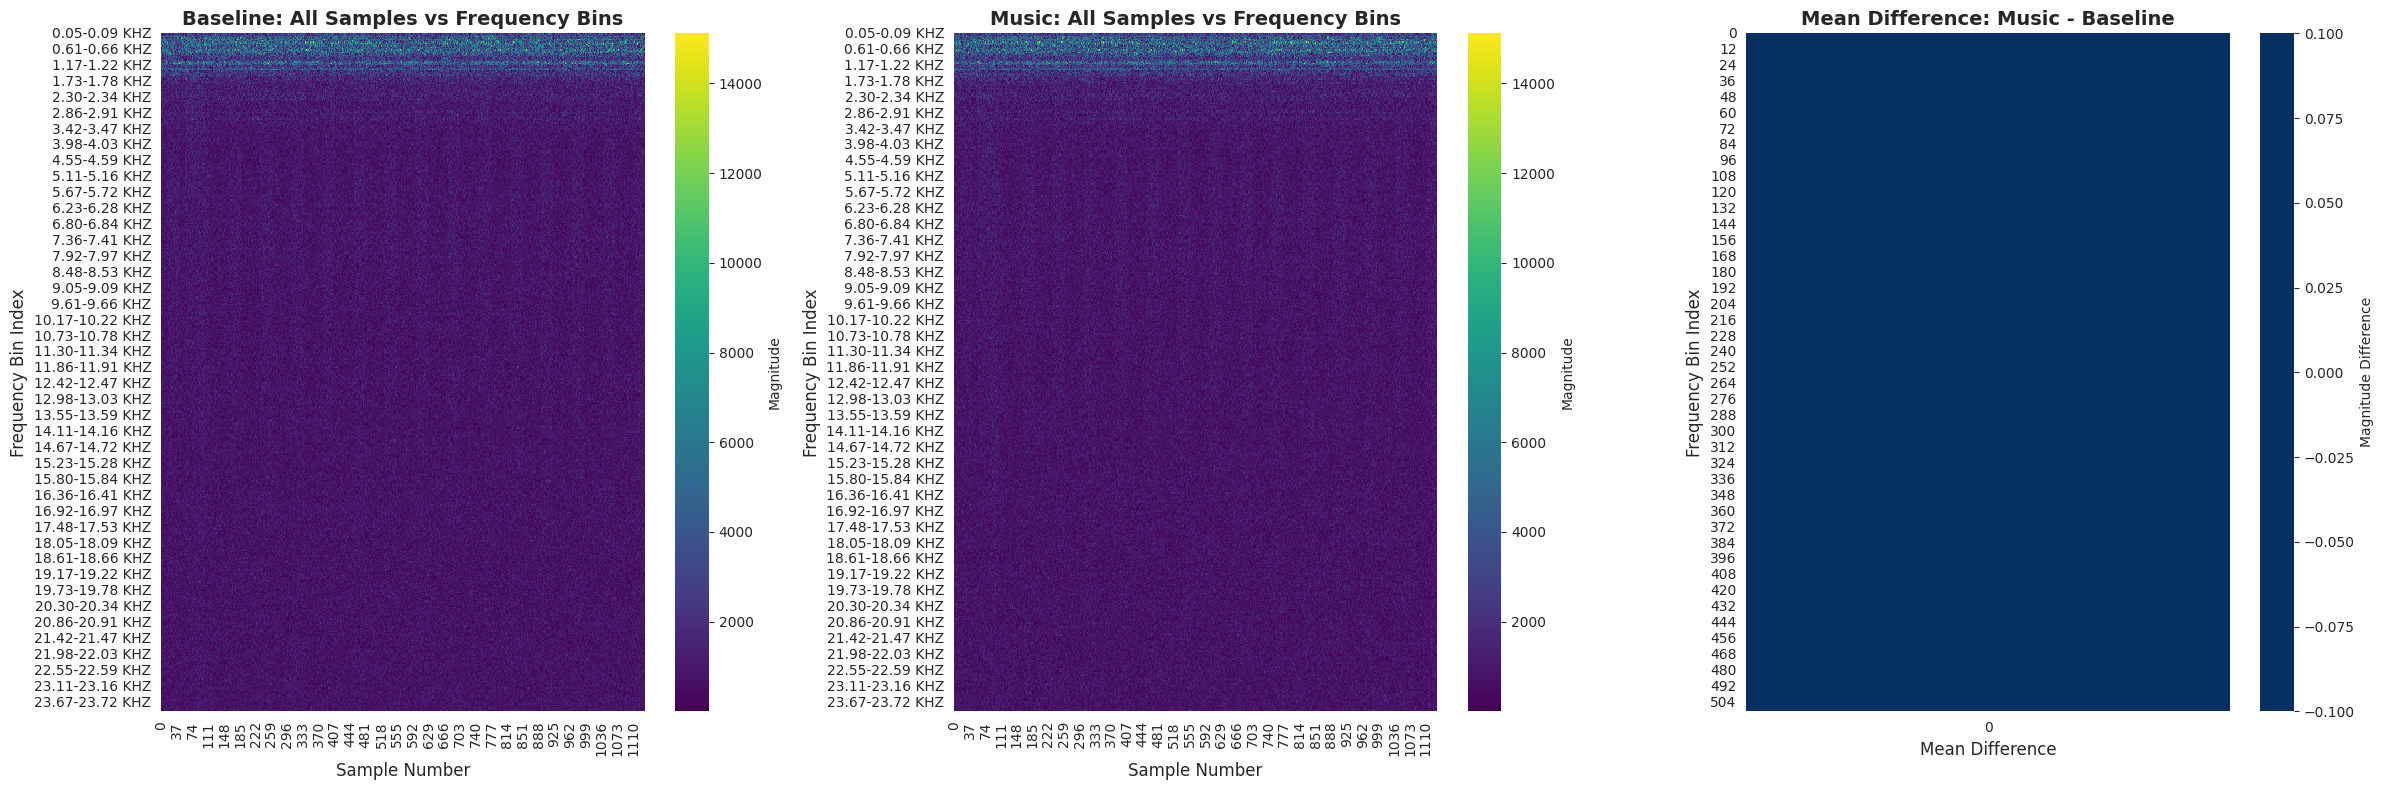

In [5]:
# Create side-by-side heatmaps
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

# Baseline heatmap
sns.heatmap(baseline_freq.T, cmap='viridis', ax=ax1, cbar_kws={'label': 'Magnitude'})
ax1.set_xlabel('Sample Number', fontsize=12)
ax1.set_ylabel('Frequency Bin Index', fontsize=12)
ax1.set_title('Baseline: All Samples vs Frequency Bins', fontsize=14, fontweight='bold')

# Music heatmap
sns.heatmap(music_freq.T, cmap='viridis', ax=ax2, cbar_kws={'label': 'Magnitude'})
ax2.set_xlabel('Sample Number', fontsize=12)
ax2.set_ylabel('Frequency Bin Index', fontsize=12)
ax2.set_title('Music: All Samples vs Frequency Bins', fontsize=14, fontweight='bold')

# Difference heatmap (average music - average baseline, broadcasted)
mean_diff = (music_mean - baseline_mean).values.reshape(-1, 1)
sns.heatmap(mean_diff, cmap='RdBu_r', center=0, ax=ax3, 
            cbar_kws={'label': 'Magnitude Difference'})
ax3.set_xlabel('Mean Difference', fontsize=12)
ax3.set_ylabel('Frequency Bin Index', fontsize=12)
ax3.set_title('Mean Difference: Music - Baseline', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

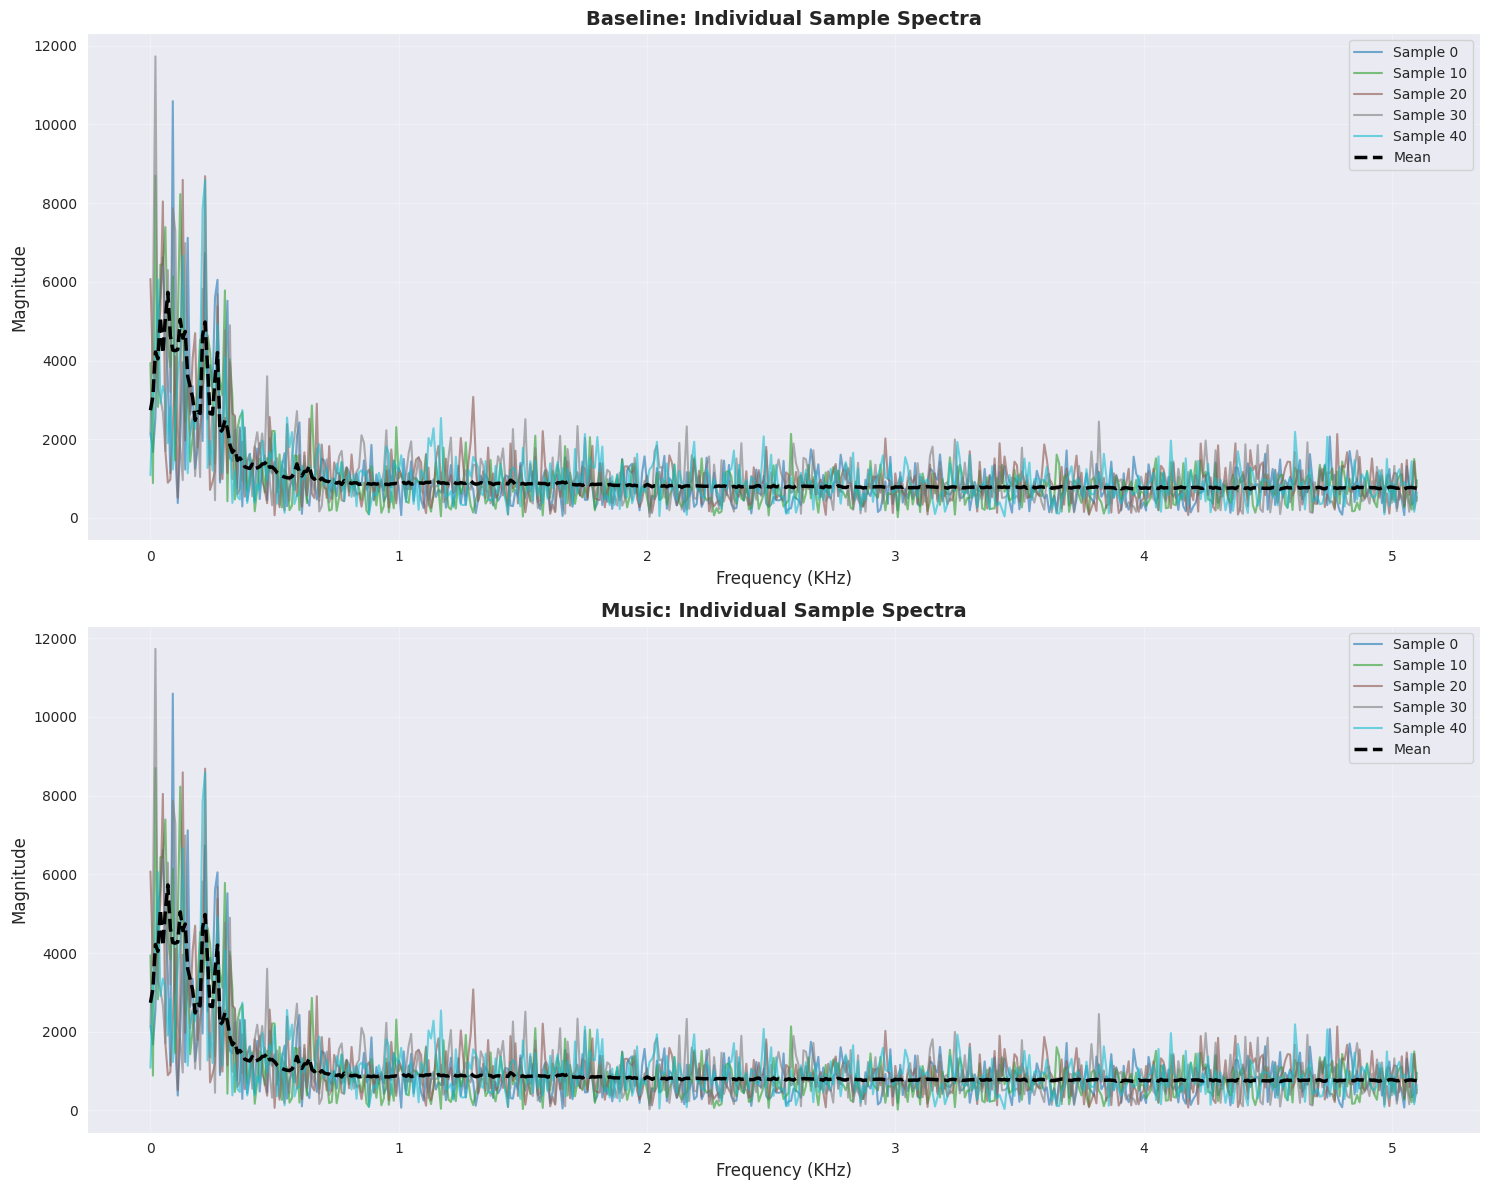

In [6]:
# Compare sample spectra from both datasets
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Select a few samples to plot
sample_indices = [0, 10, 20, 30, 40]
colors = plt.cm.tab10(np.linspace(0, 1, len(sample_indices)))

# Top plot: Baseline samples
for idx, color in zip(sample_indices, colors):
    if idx < len(baseline_freq):
        ax1.plot(frequencies, baseline_freq.iloc[idx], 
                 alpha=0.6, linewidth=1.5, label=f'Sample {idx}', color=color)

ax1.plot(frequencies, baseline_mean, 
         linewidth=2.5, label='Mean', color='black', linestyle='--')
ax1.set_xlabel('Frequency (KHz)', fontsize=12)
ax1.set_ylabel('Magnitude', fontsize=12)
ax1.set_title('Baseline: Individual Sample Spectra', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# Bottom plot: Music samples
for idx, color in zip(sample_indices, colors):
    if idx < len(music_freq):
        ax2.plot(frequencies, music_freq.iloc[idx], 
                 alpha=0.6, linewidth=1.5, label=f'Sample {idx}', color=color)

ax2.plot(frequencies, music_mean, 
         linewidth=2.5, label='Mean', color='black', linestyle='--')
ax2.set_xlabel('Frequency (KHz)', fontsize=12)
ax2.set_ylabel('Magnitude', fontsize=12)
ax2.set_title('Music: Individual Sample Spectra', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

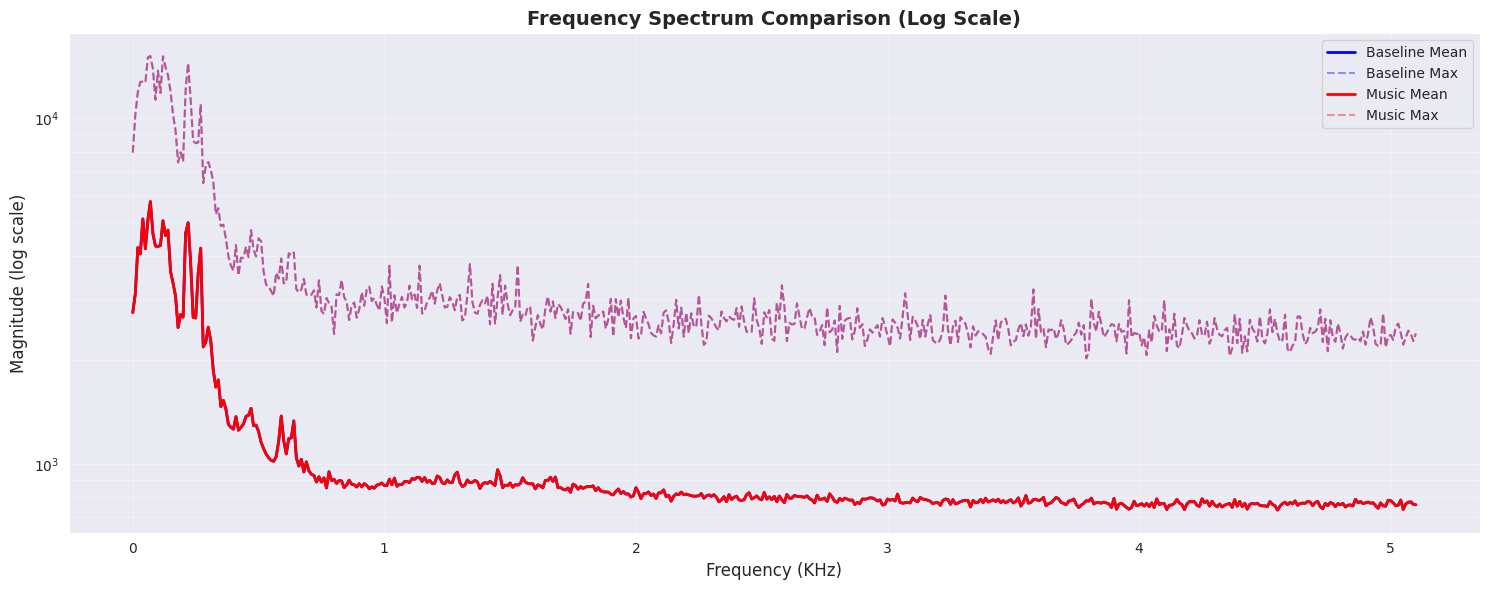

In [7]:
# Log-scale plot comparison
baseline_max = baseline_freq.max(axis=0)
baseline_min = baseline_freq.min(axis=0)
music_max = music_freq.max(axis=0)
music_min = music_freq.min(axis=0)

plt.figure(figsize=(15, 6))

# Baseline
plt.semilogy(frequencies, baseline_mean, linewidth=2, label='Baseline Mean', color='blue')
plt.semilogy(frequencies, baseline_max, linewidth=1.5, 
             label='Baseline Max', color='blue', alpha=0.4, linestyle='--')

# Music
plt.semilogy(frequencies, music_mean, linewidth=2, label='Music Mean', color='red')
plt.semilogy(frequencies, music_max, linewidth=1.5, 
             label='Music Max', color='red', alpha=0.4, linestyle='--')

plt.xlabel('Frequency (KHz)', fontsize=12)
plt.ylabel('Magnitude (log scale)', fontsize=12)
plt.title('Frequency Spectrum Comparison (Log Scale)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()

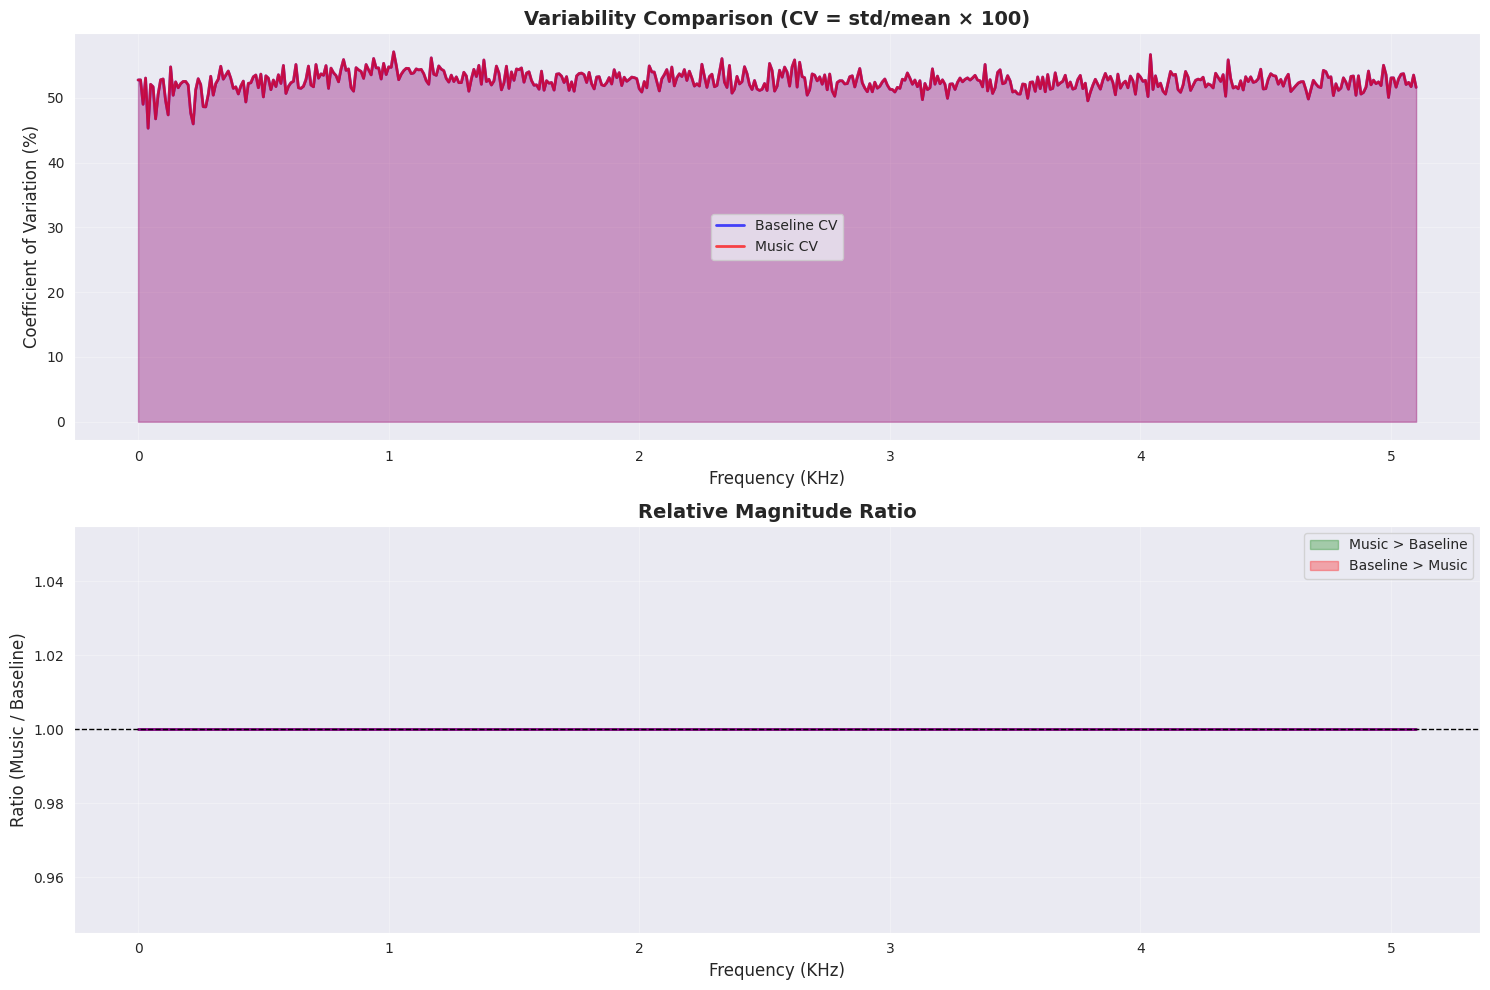

Variability Statistics:
Baseline - Mean CV: 52.63%, Max CV: 57.13%
Music - Mean CV: 52.63%, Max CV: 57.13%

Magnitude Ratio Statistics:
Max ratio (Music/Baseline): 1.00x at 0.00 KHz
Min ratio (Music/Baseline): 1.00x at 0.00 KHz


In [8]:
# Compare variability between baseline and music
baseline_cv = (baseline_std / baseline_mean) * 100
music_cv = (music_std / music_mean) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Top plot: Coefficient of variation comparison
ax1.plot(frequencies, baseline_cv, linewidth=2, color='blue', label='Baseline CV', alpha=0.7)
ax1.fill_between(frequencies, 0, baseline_cv, alpha=0.2, color='blue')
ax1.plot(frequencies, music_cv, linewidth=2, color='red', label='Music CV', alpha=0.7)
ax1.fill_between(frequencies, 0, music_cv, alpha=0.2, color='red')
ax1.set_xlabel('Frequency (KHz)', fontsize=12)
ax1.set_ylabel('Coefficient of Variation (%)', fontsize=12)
ax1.set_title('Variability Comparison (CV = std/mean × 100)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Bottom plot: Relative magnitude ratio (Music/Baseline)
# Avoid division by zero
ratio = np.where(baseline_mean > 1e-10, music_mean / baseline_mean, 1)
ax2.plot(frequencies, ratio, linewidth=2, color='purple')
ax2.fill_between(frequencies, 1, ratio, where=(ratio > 1), 
                 alpha=0.3, color='green', label='Music > Baseline')
ax2.fill_between(frequencies, 1, ratio, where=(ratio < 1), 
                 alpha=0.3, color='red', label='Baseline > Music')
ax2.axhline(y=1, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Frequency (KHz)', fontsize=12)
ax2.set_ylabel('Ratio (Music / Baseline)', fontsize=12)
ax2.set_title('Relative Magnitude Ratio', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print("Variability Statistics:")
print(f"Baseline - Mean CV: {baseline_cv.mean():.2f}%, Max CV: {baseline_cv.max():.2f}%")
print(f"Music - Mean CV: {music_cv.mean():.2f}%, Max CV: {music_cv.max():.2f}%")
print(f"\nMagnitude Ratio Statistics:")
print(f"Max ratio (Music/Baseline): {ratio.max():.2f}x at {frequencies[np.argmax(ratio)]:.2f} KHz")
print(f"Min ratio (Music/Baseline): {ratio.min():.2f}x at {frequencies[np.argmin(ratio)]:.2f} KHz")

In [9]:
# Create comparison summary
comparison_df = pd.DataFrame({
    'Baseline Mean': baseline_mean,
    'Music Mean': music_mean,
    'Difference': music_mean - baseline_mean,
    'Ratio (M/B)': ratio,
    'Baseline CV (%)': baseline_cv,
    'Music CV (%)': music_cv
}, index=freq_columns)

print("="*80)
print("TOP 10 FREQUENCY BINS WITH LARGEST INCREASES (Music > Baseline)")
print("="*80)
top_increases = comparison_df.nlargest(10, 'Difference')
print(top_increases[['Baseline Mean', 'Music Mean', 'Difference', 'Ratio (M/B)']])

print("\n" + "="*80)
print("TOP 10 FREQUENCY BINS WITH LARGEST DECREASES (Baseline > Music)")
print("="*80)
top_decreases = comparison_df.nsmallest(10, 'Difference')
print(top_decreases[['Baseline Mean', 'Music Mean', 'Difference', 'Ratio (M/B)']])

print("\n" + "="*80)
print("TOP 10 HIGHEST MAGNITUDE FREQUENCIES IN MUSIC")
print("="*80)
top_music = comparison_df.nlargest(10, 'Music Mean')
print(top_music[['Baseline Mean', 'Music Mean', 'Difference', 'Ratio (M/B)']])

print("\n" + "="*80)
print("OVERALL COMPARISON STATISTICS")
print("="*80)
print(f"\nBaseline:")
print(f"  Total samples: {len(baseline)}")
print(f"  Mean magnitude (overall): {baseline_mean.mean():.6f}")
print(f"  Std magnitude (overall): {baseline_mean.std():.6f}")
print(f"  Peak frequency: {frequencies[np.argmax(baseline_mean)]:.2f} KHz")
print(f"  Peak magnitude: {baseline_mean.max():.6f}")

print(f"\nMusic:")
print(f"  Total samples: {len(music)}")
print(f"  Mean magnitude (overall): {music_mean.mean():.6f}")
print(f"  Std magnitude (overall): {music_mean.std():.6f}")
print(f"  Peak frequency: {frequencies[np.argmax(music_mean)]:.2f} KHz")
print(f"  Peak magnitude: {music_mean.max():.6f}")

print(f"\nDifference:")
print(f"  Mean absolute difference: {np.abs(music_mean - baseline_mean).mean():.6f}")
print(f"  Max positive difference: {(music_mean - baseline_mean).max():.6f}")
print(f"  Max negative difference: {(music_mean - baseline_mean).min():.6f}")
print(f"  Correlation coefficient: {np.corrcoef(baseline_mean, music_mean)[0,1]:.4f}")

TOP 10 FREQUENCY BINS WITH LARGEST INCREASES (Music > Baseline)
               Baseline Mean   Music Mean  Difference  Ratio (M/B)
0.05-0.09 KHZ    2738.143025  2738.143025         0.0          1.0
0.09-0.14 KHZ    3101.463342  3101.463342         0.0          1.0
0.14-0.19 KHZ    4217.770040  4217.770040         0.0          1.0
0.19-0.23 KHZ    4044.270228  4044.270228         0.0          1.0
0.23-0.28 KHZ    5108.301253  5108.301253         0.0          1.0
0.28-0.33 KHZ    4185.791651  4185.791651         0.0          1.0
0.33-0.38 KHZ    5071.312017  5071.312017         0.0          1.0
0.38-0.42 KHZ    5732.788874  5732.788874         0.0          1.0
0.42-0.47 KHZ    4631.604278  4631.604278         0.0          1.0
0.47-0.52 KHZ    4264.985357  4264.985357         0.0          1.0

TOP 10 FREQUENCY BINS WITH LARGEST DECREASES (Baseline > Music)
               Baseline Mean   Music Mean  Difference  Ratio (M/B)
0.05-0.09 KHZ    2738.143025  2738.143025         0.0          1.0


## Frequency Range Distribution Comparison

/tmp/ipykernel_65178/1416421165.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(baseline_box_data, labels=box_labels, patch_artist=True)
/tmp/ipykernel_65178/1416421165.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(music_box_data, labels=box_labels, patch_artist=True)


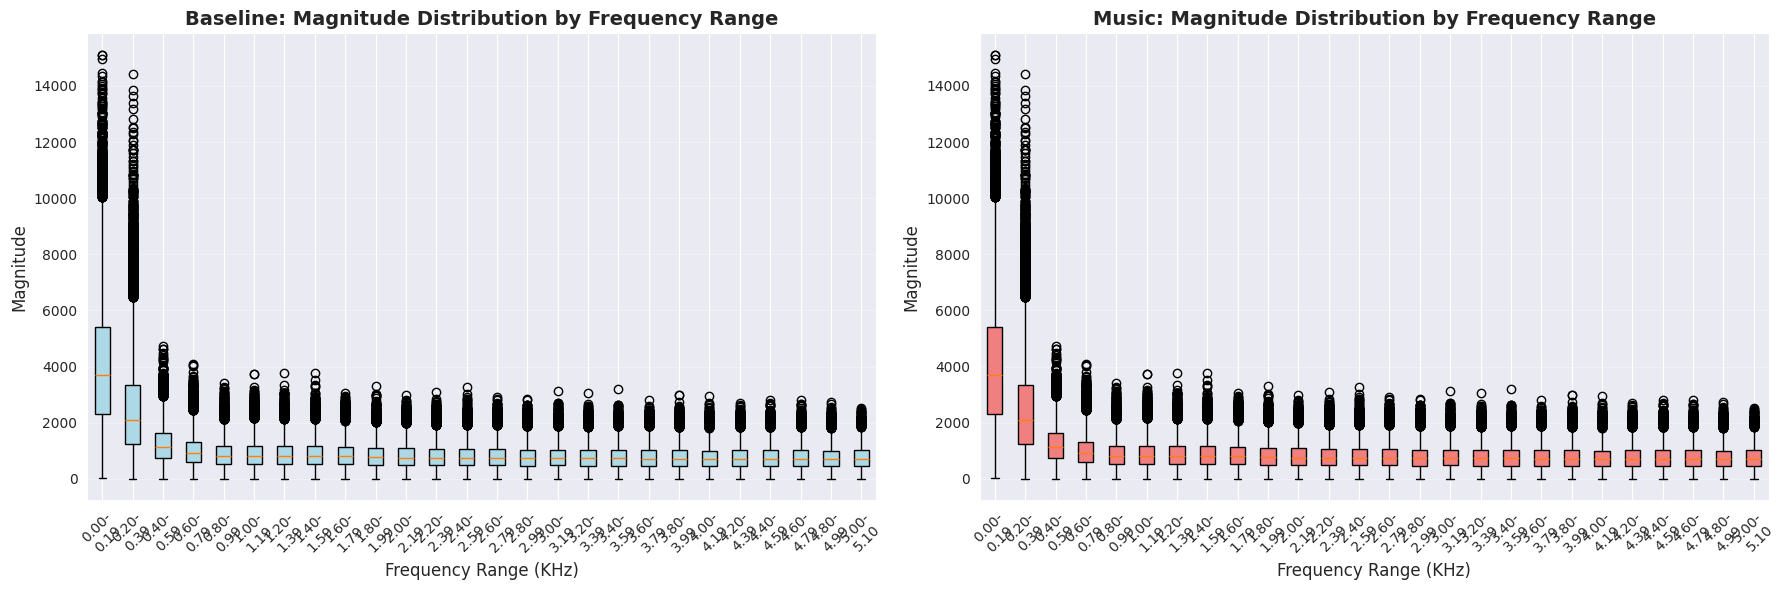

In [10]:
# Group frequency bins and compare distributions
n_bins_per_group = 20
n_groups = len(freq_columns) // n_bins_per_group + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Prepare box plot data
baseline_box_data = []
music_box_data = []
box_labels = []

for i in range(0, len(freq_columns), n_bins_per_group):
    end_idx = min(i + n_bins_per_group, len(freq_columns))
    
    baseline_range = baseline_freq.iloc[:, i:end_idx]
    music_range = music_freq.iloc[:, i:end_idx]
    
    baseline_box_data.append(baseline_range.values.flatten())
    music_box_data.append(music_range.values.flatten())
    
    start_freq = frequencies[i]
    end_freq = frequencies[min(end_idx-1, len(frequencies)-1)]
    box_labels.append(f'{start_freq:.2f}-\n{end_freq:.2f}')

# Left plot: Baseline
bp1 = ax1.boxplot(baseline_box_data, labels=box_labels, patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')
ax1.set_xlabel('Frequency Range (KHz)', fontsize=12)
ax1.set_ylabel('Magnitude', fontsize=12)
ax1.set_title('Baseline: Magnitude Distribution by Frequency Range', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# Right plot: Music
bp2 = ax2.boxplot(music_box_data, labels=box_labels, patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('lightcoral')
ax2.set_xlabel('Frequency Range (KHz)', fontsize=12)
ax2.set_ylabel('Magnitude', fontsize=12)
ax2.set_title('Music: Magnitude Distribution by Frequency Range', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# ========== CONFIGURATION ==========
# Change this to 'baseline' or 'music' to plot samples from that dataset
DATASET_TO_PLOT = 'music'  # Options: 'baseline' or 'music'
# ===================================

from ipywidgets import interact, IntSlider, Play, jslink
from IPython.display import display

# Select the dataset based on configuration
if DATASET_TO_PLOT.lower() == 'baseline':
    data_to_plot = baseline_freq
    dataset_name = 'Baseline'
    plot_color = 'blue'
elif DATASET_TO_PLOT.lower() == 'music':
    data_to_plot = music_freq
    dataset_name = 'Music'
    plot_color = 'red'
else:
    raise ValueError(f"Invalid dataset: {DATASET_TO_PLOT}. Must be 'baseline' or 'music'")

# Calculate mean for reference
mean_values = data_to_plot.mean(axis=0)

# Create interactive plot function
def plot_sample(sample_idx):
    fig, ax = plt.subplots(figsize=(15, 6))
    
    # Plot the selected sample
    ax.plot(frequencies, data_to_plot.iloc[sample_idx], 
            linewidth=2, label=f'Sample {sample_idx}', color=plot_color, alpha=0.8)
    
    # Plot the mean for reference
    ax.plot(frequencies, mean_values, 
            linewidth=2, label='Mean', color='black', linestyle='--', alpha=0.6)
    
    ax.set_xlabel('Frequency (KHz)', fontsize=12)
    ax.set_ylabel('Magnitude (Normalized)', fontsize=12)
    ax.set_title(f'{dataset_name}: Sample {sample_idx} of {len(data_to_plot)-1}', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    
    # Set consistent y-axis limits for all samples
    ax.set_ylim([data_to_plot.min().min() * 0.9, data_to_plot.max().max() * 1.1])
    
    plt.tight_layout()
    plt.show()

# Create play widget for animation
play = Play(
    value=0,
    min=0,
    max=len(data_to_plot)-1,
    step=1,
    interval=500,  # milliseconds between frames
    description="Play",
    disabled=False
)

# Create slider widget
slider = IntSlider(
    value=0,
    min=0,
    max=len(data_to_plot)-1,
    step=1,
    description='Sample:',
    continuous_update=False
)

# Link play button to slider
jslink((play, 'value'), (slider, 'value'))

# Display controls
display(play, slider)

# Create interactive plot
interact(plot_sample, sample_idx=slider)

print(f"\nUse the play button to animate through all {len(data_to_plot)} samples")
print(f"Or use the slider to manually select a specific sample")
print(f"Frequency range: {frequencies[0]:.2f} - {frequencies[-1]:.2f} KHz")

Play(value=0, description='Play', interval=500, max=1137)

IntSlider(value=0, continuous_update=False, description='Sample:', max=1137)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Sample:', max=1137), Output()),…


Use the play button to animate through all 1138 samples
Or use the slider to manually select a specific sample
Frequency range: 0.00 - 5.10 KHz
